In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
from  sklearn.model_selection import train_test_split

In [4]:
data=pd.read_csv("heart[1].csv")
df=pd.DataFrame(data)

In [5]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


<Axes: >

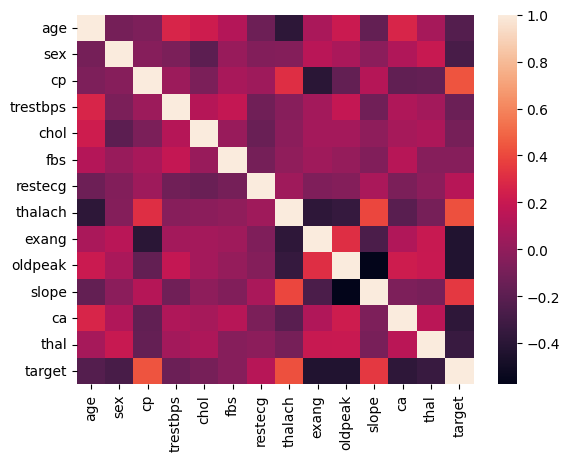

In [7]:
sns.heatmap(df.corr())

In [8]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [9]:
df=df.drop(["cp","trestbps","restecg","thalach","exang","slope","ca","thal"],axis=1)

In [10]:
df

,age,sex,chol,fbs,oldpeak,target
0,52,1,212,0,1.0,0
1,53,1,203,1,3.1,0
2,70,1,174,0,2.6,0
3,61,1,203,0,0.0,0
4,62,0,294,1,1.9,0
...,...,...,...,...,...,...
1020,59,1,221,0,0.0,1
1021,60,1,258,0,2.8,0
1022,47,1,275,0,1.0,0
1023,50,0,254,0,0.0,1


<Axes: >

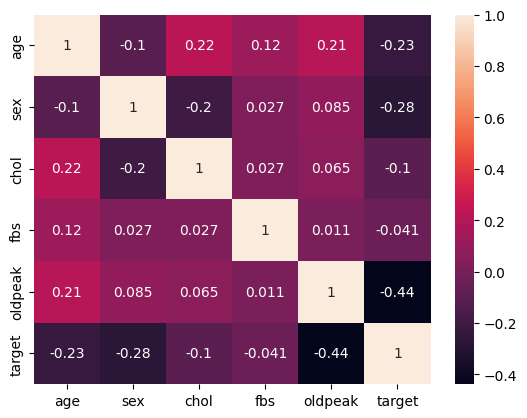

In [11]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [12]:
df

,age,sex,chol,fbs,oldpeak,target
0,52,1,212,0,1.0,0
1,53,1,203,1,3.1,0
2,70,1,174,0,2.6,0
3,61,1,203,0,0.0,0
4,62,0,294,1,1.9,0
...,...,...,...,...,...,...
1020,59,1,221,0,0.0,1
1021,60,1,258,0,2.8,0
1022,47,1,275,0,1.0,0
1023,50,0,254,0,0.0,1


In [13]:
from sklearn.preprocessing import StandardScaler
se=StandardScaler()

In [14]:
scaled_col=["age","chol","oldpeak"]
df[scaled_col]=se.fit_transform(df[scaled_col])

In [15]:
df # Df is scaled

,age,sex,chol,fbs,oldpeak,target
0,-0.268437,1,-0.659332,0,-0.060888,0
1,-0.158157,1,-0.833861,1,1.727137,0
2,1.716595,1,-1.396233,0,1.301417,0
3,0.724079,1,-0.833861,0,-0.912329,0
4,0.834359,0,0.930822,1,0.705408,0
...,...,...,...,...,...,...
1020,0.503520,1,-0.484803,0,-0.912329,1
1021,0.613800,1,0.232705,0,1.471705,0
1022,-0.819834,1,0.562371,0,-0.060888,0
1023,-0.488996,0,0.155137,0,-0.912329,1


In [16]:
X=df.drop("target",axis=1)
Y=df["target"]

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,random_state=42,test_size=0.2)

In [18]:
x_train

,age,sex,chol,fbs,oldpeak
835,-0.599275,1,-1.881036,0,-0.231177
137,1.054918,0,1.531978,0,-0.912329
534,-0.047877,0,0.407235,0,-0.912329
495,0.503520,1,-0.232705,0,-0.486609
244,-0.378716,1,-0.019392,1,1.131129
...,...,...,...,...,...
700,-1.481512,1,-0.620548,0,0.790552
71,0.724079,1,-0.756293,0,0.705408
106,-0.378716,1,1.027782,0,0.449976
270,-1.260953,1,-0.678724,0,-0.912329


In [19]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [20]:
models={
    "logistic regression ":LogisticRegression(),
    "kNN":KNeighborsClassifier(),
    "naive byeas ":GaussianNB(),
    "decision tree ":DecisionTreeClassifier(),
    "svm":SVC()
}

In [21]:
result=[]

In [22]:
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    acc=accuracy_score(y_pred,y_test)
    f1=f1_score(y_pred,y_test)
    result.append({
        "model":name,
        "accuracy":acc,
        "F1_score":f1
    })


In [23]:
result

[{'model': 'logistic regression ',
  'accuracy': 0.7121951219512195,
  'F1_score': 0.7177033492822966},
 {'model': 'kNN',
  'accuracy': 0.697560975609756,
  'F1_score': 0.696078431372549},
 {'model': 'naive byeas ',
  'accuracy': 0.7073170731707317,
  'F1_score': 0.7297297297297297},
 {'model': 'decision tree ',
  'accuracy': 0.9853658536585366,
  'F1_score': 0.9852216748768473},
 {'model': 'svm',
  'accuracy': 0.697560975609756,
  'F1_score': 0.7102803738317757}]

In [24]:
de=DecisionTreeClassifier()
de.fit(x_train,y_train)

train_acc=de.score(x_train,y_train)
test_acc=de.score(x_test,y_test)

In [25]:
print(train_acc,test_acc)

1.0 0.9853658536585366


In [26]:
y_train_pred=de.predict(x_train)
y_test_pred=de.predict(x_test)

In [27]:
print(accuracy_score(y_train_pred,y_train))
print(accuracy_score(y_test_pred,y_test))


1.0
0.9853658536585366


In [28]:
import joblib 
joblib.dump(models["decision tree "],"decison.pkl")
joblib.dump(se,"scaler.pkl")
joblib.dump(X.columns.tolist(),"columns.pkl")


['columns.pkl']

In [29]:
df.columns

Index(['age', 'sex', 'chol', 'fbs', 'oldpeak', 'target'], dtype='object')